# EduInsight: Data Understanding

## Objective

This notebook investigates the structure and quality of the Open
University Learning Analytics Dataset before data cleaning, analysis,
and model development.

## Main research question

How can early course engagement and assessment activity help identify
students who may benefit from additional academic support?

Rows and columns: (32593, 12)

Column names:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              32593 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          3259

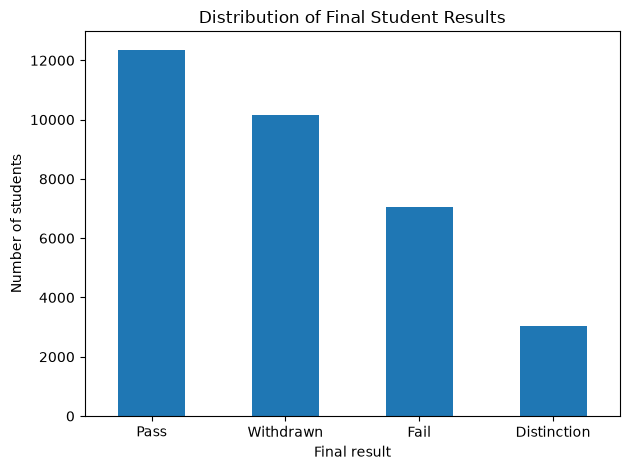

In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

student_info_path = RAW_DATA_DIR / "studentInfo.csv"

if not student_info_path.exists():
    raise FileNotFoundError(
        f"Could not find {student_info_path}. "
        "Confirm that the dataset was extracted into data/raw."
    )

student_info = pd.read_csv(student_info_path)

student_info.head()
print("Rows and columns:", student_info.shape)
print("\nColumn names:")
print(student_info.columns.tolist())

student_info.info()

missing_summary = (
    student_info.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"] / len(student_info) * 100
).round(2)

missing_summary

duplicate_rows = student_info.duplicated().sum()
print("Exact duplicate rows:", duplicate_rows)

key_columns = [
    "code_module",
    "code_presentation",
    "id_student",
]

duplicate_keys = student_info.duplicated(
    subset=key_columns,
    keep=False,
).sum()

print("Rows with duplicated composite keys:", duplicate_keys)

result_counts = student_info["final_result"].value_counts()
result_percentages = (
    student_info["final_result"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

result_summary = pd.DataFrame({
    "count": result_counts,
    "percentage": result_percentages,
})

result_summary

result_counts.plot(kind="bar")

plt.title("Distribution of Final Student Results")
plt.xlabel("Final result")
plt.ylabel("Number of students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The dataset contains four final-result categories: Pass, Fail,
Withdrawn, and Distinction. The categories are not equally represented,
so accuracy alone may not be sufficient when evaluating a future
classification model.

In [6]:
presentation_counts = (
    student_info
    .groupby(["code_module", "code_presentation"])
    .size()
    .sort_values(ascending=False)
    .rename("student_count")
    .reset_index()
)

presentation_counts

,code_module,code_presentation,student_count
0,CCC,2014J,2498
1,FFF,2014J,2365
2,BBB,2014J,2292
3,FFF,2013J,2283
4,BBB,2013J,2237
5,DDD,2013J,1938
6,CCC,2014B,1936
7,DDD,2014J,1803
8,BBB,2013B,1767
9,FFF,2013B,1614


In [7]:
SELECTED_MODULE = "BBB"
SELECTED_PRESENTATION = "2013J"
selected_students = student_info[
    (student_info["code_module"] == SELECTED_MODULE)
    & (
        student_info["code_presentation"]
        == SELECTED_PRESENTATION
    )
].copy()

selected_students.shape

(2237, 12)